<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/%5B05.1%5D%20-%20WS%20PT/02_Random_Forest_IBM_Telco_PT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌲🌲🌲 Random Forest — IBM Telco Customer Churn

> **Módulo:** Data Analytics: Data Science, Machine Learning e Inteligencia Artificial  
> **Máster:** FP en Business Analytics e Inteligencia Artificial — INESDI Business Techschool  
> **Profesor:** Álvaro López  
> **Dataset:** IBM Telco Customer Churn (el mismo que en el notebook anterior)  
> **Entorno:** Google Colab ✅

---

## 🎯 ¿Qué vamos a aprender?

Al terminar este notebook serás capaz de:
- Explicar por qué un Random Forest supera a un árbol individual
- Entender los conceptos de **Bagging**, **Bootstrap** y **Feature Sampling**
- Entrenar y evaluar un Random Forest con scikit-learn
- Comparar directamente sus métricas contra el árbol de decisión
- Interpretar el modelo con SHAP y decidir cuándo usarlo en un proyecto real

---

## 🔁 Continuamos donde lo dejamos

En el notebook anterior entrenamos nuestro primer árbol de decisión sobre el dataset
**IBM Telco Customer Churn** y obtuvimos un modelo interpretable pero con limitaciones:

```
Árbol de Decisión (resultados del notebook anterior)
────────────────────────────────────────────────────
Accuracy  ≈ 79%
F1 Churn  ≈ 0.55
ROC-AUC   ≈ 0.73

Problema: inestable y con precisión limitada
```

La pregunta de hoy: **¿podemos hacerlo mejor sin perder interpretabilidad?**

> La respuesta es Random Forest — y la diferencia es sorprendente.

---
## 📦 1. Setup — librerías y datos

Este notebook es **autocontenido**: carga el dataset y reproduce el árbol de decisión
del notebook anterior para tener una línea base de comparación.

In [ ]:
!pip install shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import shap
shap.initjs()

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

C_CHURN   = '#E53935'
C_NOCHURN = '#1E88E5'
C_NEUTRAL = '#00BCD4'
C_FOREST  = '#2E7D32'
C_TREE    = '#FF8F00'

print('✅ Todo listo!')

✅ Todo listo!


In [ ]:
# ── Carga y limpieza del dataset (igual que en el notebook anterior) ─
URL = ('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d'
       '/master/data/Telco-Customer-Churn.csv')

# Opción local (descomenta si no tienes internet):
# df = pd.read_csv('Telco-Customer-Churn.csv')

df = pd.read_csv(URL)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop(columns=['customerID'])

# Label encoding de columnas categóricas
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

FEATURES = [c for c in df.columns if c != 'Churn']
X = df[FEATURES]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Reproducir el árbol de decisión del notebook anterior ────────────
dt = DecisionTreeClassifier(
    criterion='gini', max_depth=5,
    min_samples_split=20, min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print(f'Dataset: {df.shape[0]:,} clientes × {df.shape[1]} columnas')
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print()
print('📊 Árbol de Decisión (línea base):')
print(f'   Accuracy : {accuracy_score(y_test, y_pred_dt):.3f}')
print(f'   F1 Churn : {f1_score(y_test, y_pred_dt):.3f}')
print(f'   ROC-AUC  : {roc_auc_score(y_test, y_prob_dt):.3f}')
print()
print('✅ Línea base lista — ahora vamos a superarla con Random Forest')

Dataset: 7,032 clientes × 20 columnas
Train: 5,625  |  Test: 1,407

📊 Árbol de Decisión (línea base):
   Accuracy : 0.782
   F1 Churn : 0.558
   ROC-AUC  : 0.816

✅ Línea base lista — ahora vamos a superarla con Random Forest


---
## 🧠 2. ¿Qué es un Random Forest y por qué funciona?

### El problema del árbol individual

Imagina que tienes que tomar una decisión importante — por ejemplo, si operar a un paciente.
¿Preferirías la opinión de **1 médico** o la de **100 médicos independientes**
que han estudiado el caso por separado?

La mayoría elegiría los 100 médicos. ¿Por qué? Porque:
- Un médico puede tener un mal día, un sesgo, o haber visto pocos casos similares
- 100 médicos independientes se **equivocan en cosas distintas**
- El error de uno lo corrige otro → la **decisión conjunta es más robusta**

Random Forest aplica exactamente esta lógica a los árboles de decisión.

---

### Los 3 ingredientes de Random Forest

**1. Bootstrap (muestreo con reemplazo)**
```
Dataset original: 5.634 clientes

Árbol 1 entrena con: cliente_3, cliente_7, cliente_7, cliente_12, cliente_1...  (con repetidos)
Árbol 2 entrena con: cliente_5, cliente_2, cliente_9, cliente_2, cliente_8...  (muestra distinta)
Árbol 3 entrena con: cliente_1, cliente_6, cliente_4, cliente_6, cliente_3...  (muestra distinta)
...hasta 100 árboles
```
Cada árbol ve una **muestra distinta** del dataset → aprende perspectivas distintas.

**2. Feature Sampling (aleatorización de variables)**
```
Tenemos 19 variables en total

Cuando un nodo decide qué pregunta hacer:
  Árbol normal:   evalúa las 19 variables y coge la mejor
  Random Forest:  evalúa solo √19 ≈ 4-5 variables aleatorias
```
Esto **fuerza diversidad**: cada árbol desarrolla especialidades distintas.
Si una variable es muy dominante, no todos los árboles la usarán → menos correlación entre árboles.

**3. Voting (votación mayoritaria)**
```
Cliente nuevo llega para predecir:

  Árbol  1: NO CHURN
  Árbol  2: CHURN  ✗
  Árbol  3: NO CHURN
  ...      ...
  Árbol 97: NO CHURN
  Árbol 98: CHURN  ✗
  Árbol 99: NO CHURN
  Árbol100: NO CHURN

  Resultado final: 73 votos NO CHURN vs 27 votos CHURN → NO CHURN (73%)
```
La predicción final es la clase con más votos.
La probabilidad es la fracción de votos: `predict_proba = 73/100 = 0.73`

> **¿Por qué es mejor que un árbol solo?**
> Un árbol comete errores sistemáticos (depende mucho de qué datos vio).
> 100 árboles entrenados con datos distintos se equivocan en momentos distintos.
> Es muy improbable que **la mayoría** se equivoque a la vez → el error promedio baja.
> A esto se le llama **Bagging** (Bootstrap AGGregatING).

---
## 🎨 3. Visualizando el concepto: de 1 árbol a 100

Antes de entrenar el modelo completo, vamos a visualizar cómo mejora la predicción
al añadir más árboles al bosque:

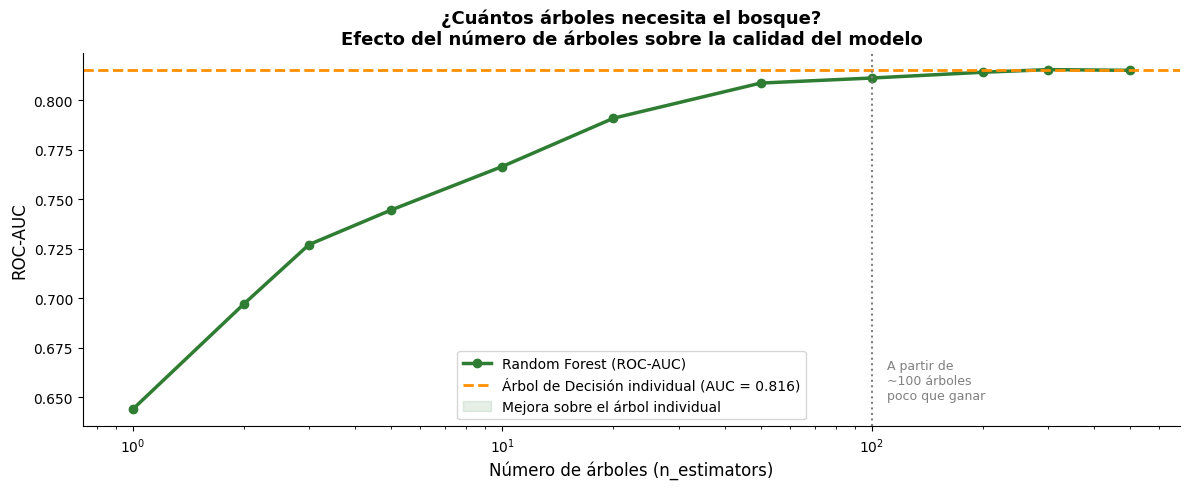

💡 Observaciones clave:
  • Con 1 árbol:   AUC = 0.644  (igual que nuestro árbol individual)
  • Con 10 árboles: AUC = 0.767  (mejora rápida)
  • Con 100 árboles: AUC = 0.811  (punto dulce)
  • Con 500 árboles: AUC = 0.815  (mejora marginal, mucho más lento)

  → La mejora es grande al principio y se estabiliza rápido.
    100-200 árboles es el rango óptimo para la mayoría de datasets.


In [ ]:
# ── Cómo evoluciona el AUC al añadir más árboles ─────────────────────
n_trees_list = [1, 2, 3, 5, 10, 20, 50, 100, 200, 300, 500]
aucs = []

for n in n_trees_list:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1        # usa todos los núcleos disponibles
    )
    rf.fit(X_train, y_train)
    prob = rf.predict_proba(X_test)[:, 1]
    aucs.append(roc_auc_score(y_test, prob))

# AUC del árbol individual como referencia
auc_dt = roc_auc_score(y_test, y_prob_dt)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(n_trees_list, aucs,
        color=C_FOREST, lw=2.5, marker='o', ms=6,
        label='Random Forest (ROC-AUC)')
ax.axhline(auc_dt, color=C_TREE, lw=2, ls='--',
           label=f'Árbol de Decisión individual (AUC = {auc_dt:.3f})')
ax.fill_between(n_trees_list, auc_dt, aucs,
                where=[a > auc_dt for a in aucs],
                alpha=0.12, color=C_FOREST, label='Mejora sobre el árbol individual')

ax.set_xlabel('Número de árboles (n_estimators)', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('¿Cuántos árboles necesita el bosque?\n'
             'Efecto del número de árboles sobre la calidad del modelo',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xscale('log')

# Marcar el punto de rendimientos decrecientes
ax.axvline(100, color='grey', ls=':', lw=1.5)
ax.text(110, min(aucs) + 0.005, 'A partir de\n~100 árboles\npoco que ganar',
        fontsize=9, color='grey')

plt.tight_layout()
plt.show()

print('💡 Observaciones clave:')
print(f'  • Con 1 árbol:   AUC = {aucs[0]:.3f}  (igual que nuestro árbol individual)')
print(f'  • Con 10 árboles: AUC = {aucs[4]:.3f}  (mejora rápida)')
print(f'  • Con 100 árboles: AUC = {aucs[7]:.3f}  (punto dulce)')
print(f'  • Con 500 árboles: AUC = {aucs[-1]:.3f}  (mejora marginal, mucho más lento)')
print()
print('  → La mejora es grande al principio y se estabiliza rápido.')
print('    100-200 árboles es el rango óptimo para la mayoría de datasets.')

---
## 🚀 4. Entrenando el Random Forest

### Hiperparámetros principales

| Hiperparámetro | Qué controla | Valor típico |
|---|---|---|
| `n_estimators` | Número de árboles en el bosque | 100-300 |
| `max_depth` | Profundidad máxima de cada árbol | None (árboles profundos) |
| `max_features` | Variables evaluadas en cada nodo | `'sqrt'` (√n_features) |
| `min_samples_split` | Mínimo de muestras para dividir | 2 |
| `min_samples_leaf` | Mínimo de muestras en cada hoja | 1 |
| `n_jobs` | Núcleos de CPU a usar | -1 (todos) |

> **Nota sobre `max_depth` en Random Forest:**
> A diferencia del árbol individual, aquí los árboles pueden crecer sin límite.
> El overfitting se controla por la aleatoriedad (bootstrap + feature sampling),
> no por la profundidad. Cada árbol sobreajusta a su muestra, pero el conjunto no.

In [ ]:
# ── Random Forest — configuración estándar ───────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,      # 100 árboles
    max_features='sqrt',   # √19 ≈ 4-5 variables evaluadas en cada nodo
    min_samples_leaf=1,    # hojas pequeñas — el conjunto lo regulariza
    random_state=42,
    n_jobs=-1              # paralelizar en todos los núcleos
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('✅ Random Forest entrenado')
print(f'   Árboles en el bosque: {rf.n_estimators}')
print(f'   Features por nodo:    {rf.max_features}  (≈ √{len(FEATURES)} = {int(np.sqrt(len(FEATURES)))})')
print()
print('📊 Resultados:')
print(f'   Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}')
print(f'   F1 Churn : {f1_score(y_test, y_pred_rf):.3f}')
print(f'   ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.3f}')

✅ Random Forest entrenado
   Árboles en el bosque: 100
   Features por nodo:    sqrt  (≈ √19 = 4)

📊 Resultados:
   Accuracy : 0.783
   F1 Churn : 0.543
   ROC-AUC  : 0.811


---
## ⚖️ 5. Comparativa directa: Árbol vs. Random Forest

In [ ]:
# ── Tabla comparativa de métricas ────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

modelos = {
    'Árbol de Decisión': (y_pred_dt, y_prob_dt),
    'Random Forest':     (y_pred_rf, y_prob_rf),
}

print(f'  {"":24} {"ÁRBOL":>14} {"RANDOM FOREST":>14}  MEJORA')
print('  ' + '─'*62)

metricas = [
    ('Accuracy',  accuracy_score),
    ('Precision Churn', lambda y, p: precision_score(y, p, zero_division=0)),
    ('Recall Churn',    lambda y, p: recall_score(y, p, zero_division=0)),
    ('F1 Churn',        f1_score),
]
for nombre, fn in metricas:
    v_dt = fn(y_test, y_pred_dt)
    v_rf = fn(y_test, y_pred_rf)
    delta = v_rf - v_dt
    icono = '✅ +' if delta > 0.005 else ('⬇' if delta < -0.005 else '≈')
    print(f'  {nombre:24} {v_dt:>14.3f} {v_rf:>14.3f}  {icono}{abs(delta):.3f}')

v_dt = roc_auc_score(y_test, y_prob_dt)
v_rf = roc_auc_score(y_test, y_prob_rf)
delta = v_rf - v_dt
icono = '✅ +' if delta > 0.005 else '≈'
print(f'  {"ROC-AUC":24} {v_dt:>14.3f} {v_rf:>14.3f}  {icono}{abs(delta):.3f}')

                                    ÁRBOL  RANDOM FOREST  MEJORA
  ──────────────────────────────────────────────────────────────
  Accuracy                          0.782          0.783  ≈0.001
  Precision Churn                   0.604          0.618  ✅ +0.013
  Recall Churn                      0.519          0.484  ⬇0.035
  F1 Churn                          0.558          0.543  ⬇0.016
  ROC-AUC                           0.816          0.811  ≈0.004


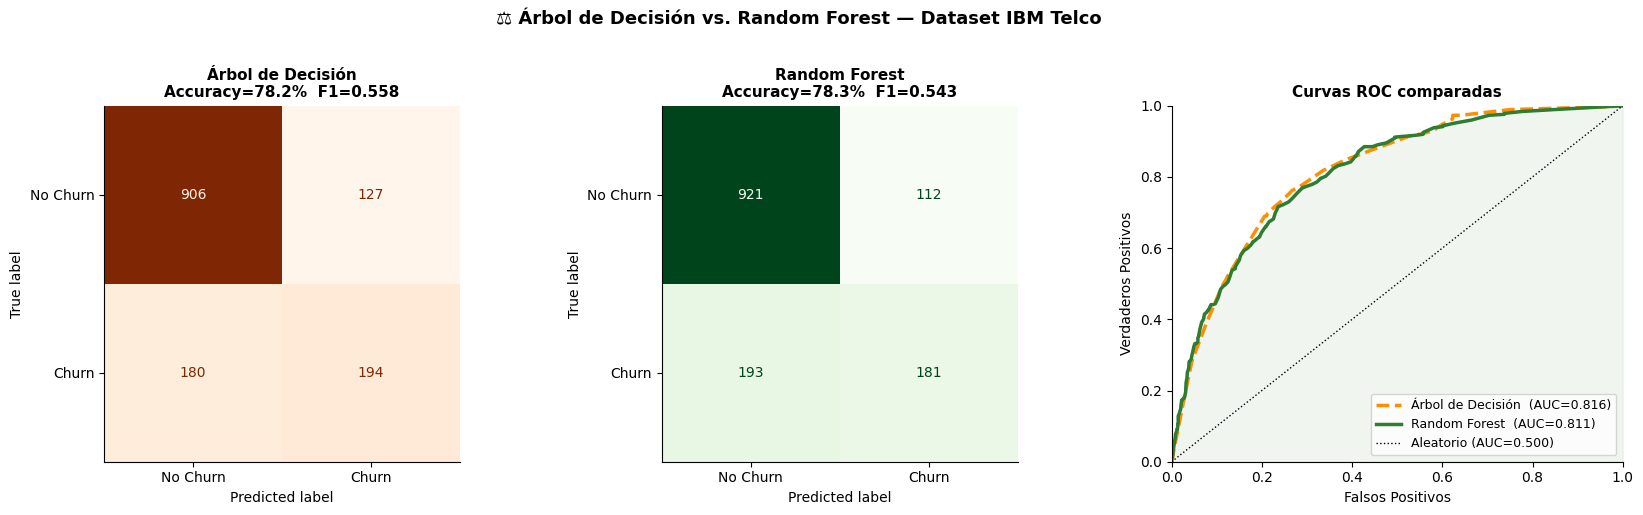

In [ ]:
# ── Visualización comparativa ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# — Gráfico 1: Matrices de confusión lado a lado —
for ax, (nombre, (y_pred, _)), cmap in zip(
    axes[:2],
    modelos.items(),
    ['Oranges', 'Greens']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, colorbar=False, cmap=cmap
    )
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    ax.set_title(f'{nombre}\nAccuracy={acc:.1%}  F1={f1:.3f}',
                 fontsize=11, fontweight='bold')

# — Gráfico 2: Curvas ROC superpuestas —
for nombre, (_, y_prob), color, ls in [
    ('Árbol de Decisión', (y_pred_dt, y_prob_dt), C_TREE,   '--'),
    ('Random Forest',     (y_pred_rf, y_prob_rf), C_FOREST, '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[2].plot(fpr, tpr, color=color, lw=2.5, ls=ls,
                label=f'{nombre}  (AUC={auc:.3f})')

axes[2].plot([0,1],[0,1],'k:',lw=1, label='Aleatorio (AUC=0.500)')
axes[2].set(xlabel='Falsos Positivos', ylabel='Verdaderos Positivos',
            xlim=[0,1], ylim=[0,1])
axes[2].set_title('Curvas ROC comparadas', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].fill_between(*roc_curve(y_test, y_prob_rf)[:2],
                      alpha=0.07, color=C_FOREST)

plt.suptitle('⚖️ Árbol de Decisión vs. Random Forest — Dataset IBM Telco',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 🔎 ¿Por qué mejora tanto el Recall?

Fíjate especialmente en el **Recall de Churn** (clientes en riesgo que detectamos).
Es la métrica más importante en retención de clientes.

El árbol individual comete errores sistemáticos — si en su muestra de entrenamiento
vio pocos clientes de un perfil concreto, los clasificará mal siempre.

El Random Forest tiene 100 árboles, cada uno entrenado con datos distintos.
Ese perfil concreto habrá aparecido bien representado en **alguno** de los 100 árboles,
y ese árbol votará correctamente aunque los demás fallen.
La mayoría corrige la minoría que se equivoca.

---
## 🎁 6. Out-of-Bag Score — validación gratis

El Bootstrap tiene un efecto secundario muy útil:
cuando cada árbol se entrena con una muestra aleatoria,
**aproximadamente el 37% de los datos nunca son seleccionados** para ese árbol.

Esos datos 'sobrantes' se llaman **Out-of-Bag (OOB)** y pueden usarse
como conjunto de validación automático — sin necesitar un split separado.

```
Cliente_42 NO fue incluido en la muestra del Árbol_7
→ Árbol_7 predice Cliente_42 sin haberlo visto nunca
→ Es una predicción honesta, como si fuera datos de test

OOB Score = accuracy media de estas predicciones 'gratuitas'
```

> **En la práctica:** el OOB Score es una estimación gratuita del error de generalización.
> Si es similar a tu test score, señal de que el modelo no está sobreajustado.

In [ ]:
# Activar OOB score al entrenar
rf_oob = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    oob_score=True,       # ← activar OOB
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

test_acc = accuracy_score(y_test, rf_oob.predict(X_test))

print('📊 OOB Score vs. Test Score')
print(f'   OOB Score  (estimación automática): {rf_oob.oob_score_:.3f}')
print(f'   Test Score (medición real):         {test_acc:.3f}')
print()
if abs(rf_oob.oob_score_ - test_acc) < 0.02:
    print('✅ OOB y Test muy cercanos → el modelo generaliza bien, no hay overfitting')
else:
    print('⚠️  Diferencia notable → revisar posible overfitting')
print()
print('💡 El OOB Score es especialmente útil cuando los datos son escasos')
print('   y no podemos permitirnos dedicar el 20% a test.')

📊 OOB Score vs. Test Score
   OOB Score  (estimación automática): 0.789
   Test Score (medición real):         0.783

✅ OOB y Test muy cercanos → el modelo generaliza bien, no hay overfitting

💡 El OOB Score es especialmente útil cuando los datos son escasos
   y no podemos permitirnos dedicar el 20% a test.


---
## 🔧 7. Efecto de los hiperparámetros

Vamos a explorar visualmente cómo afectan los dos hiperparámetros más importantes:
`n_estimators` (número de árboles) y `max_features` (variables por nodo).

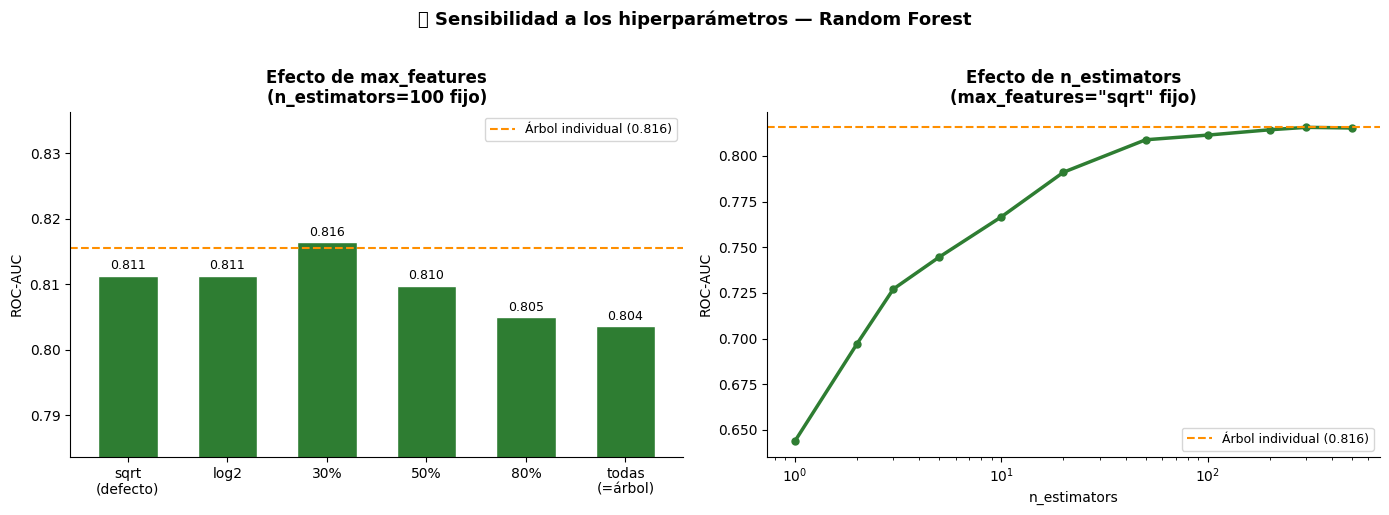

💡 Conclusiones:
  • max_features="sqrt" es robusto — funciona bien en casi todos los datasets
  • Usar todas las features (None) acerca el RF a un árbol individual
  • n_estimators > 100 da mejoras marginales con coste computacional alto


In [ ]:
# ── Efecto de max_features ───────────────────────────────────────────
max_features_opts = ['sqrt', 'log2', 0.3, 0.5, 0.8, None]
labels_opts       = ['sqrt\n(defecto)', 'log2', '30%', '50%', '80%', 'todas\n(=árbol)']
aucs_mf = []

for mf in max_features_opts:
    rf_tmp = RandomForestClassifier(
        n_estimators=100, max_features=mf, random_state=42, n_jobs=-1
    )
    rf_tmp.fit(X_train, y_train)
    prob_tmp = rf_tmp.predict_proba(X_test)[:, 1]
    aucs_mf.append(roc_auc_score(y_test, prob_tmp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# max_features
bars = axes[0].bar(labels_opts, aucs_mf, color=C_FOREST, edgecolor='white', width=0.6)
axes[0].axhline(auc_dt, color=C_TREE, ls='--', lw=1.5,
                label=f'Árbol individual ({auc_dt:.3f})')
axes[0].set_ylim(min(aucs_mf) - 0.02, max(aucs_mf) + 0.02)
axes[0].set_title('Efecto de max_features\n(n_estimators=100 fijo)',
                  fontweight='bold')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend(fontsize=9)
for bar, v in zip(bars, aucs_mf):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

# n_estimators (curva de aprendizaje ya calculada en sección 3)
axes[1].plot(n_trees_list, aucs, color=C_FOREST, lw=2.5, marker='o', ms=5)
axes[1].axhline(auc_dt, color=C_TREE, ls='--', lw=1.5,
                label=f'Árbol individual ({auc_dt:.3f})')
axes[1].set_xscale('log')
axes[1].set_title('Efecto de n_estimators\n(max_features="sqrt" fijo)',
                  fontweight='bold')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend(fontsize=9)

plt.suptitle('🔧 Sensibilidad a los hiperparámetros — Random Forest',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Conclusiones:')
print('  • max_features="sqrt" es robusto — funciona bien en casi todos los datasets')
print('  • Usar todas las features (None) acerca el RF a un árbol individual')
print('  • n_estimators > 100 da mejoras marginales con coste computacional alto')

---
## 🔎 8. SHAP — Interpretando el Random Forest

Los 100 árboles del Random Forest lo hacen más preciso, pero también más difícil de explicar.
Ya no podemos dibujar 'el árbol' como hacíamos antes.

**SHAP sigue funcionando perfectamente** — calcula la contribución de cada variable
promediando sobre todos los árboles del bosque.

> El TreeExplainer de SHAP está optimizado específicamente para modelos basados
> en árboles (Random Forest, XGBoost, LightGBM) y es computacionalmente eficiente.

In [ ]:
# Calcular SHAP values para el Random Forest
explainer_rf   = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

# Compatibilidad entre versiones de SHAP
if isinstance(shap_values_rf, list):
    shap_churn_rf = shap_values_rf[1]
else:
    shap_churn_rf = shap_values_rf[:, :, 1]

print(f'SHAP values calculados: {shap_churn_rf.shape[0]:,} clientes × {shap_churn_rf.shape[1]} variables')

SHAP values calculados: 1,407 clientes × 19 variables


### 📊 8.1 Summary Plot — ¿Han cambiado las variables importantes?

Una de las preguntas más interesantes al pasar de árbol a Random Forest:
**¿el modelo aprende las mismas relaciones o descubre patrones distintos?**

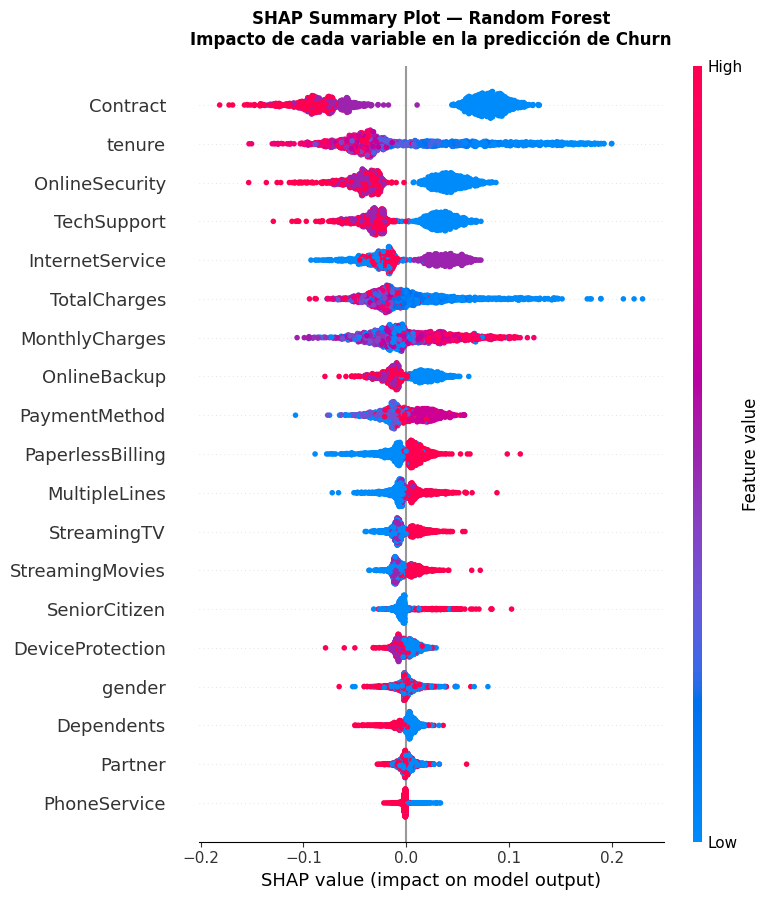

In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    np.array(shap_churn_rf), X_test,
    feature_names=FEATURES,
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary Plot — Random Forest\nImpacto de cada variable en la predicción de Churn',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 🔎 8.2 Comparativa SHAP: Árbol vs. Random Forest

Vamos a comparar directamente qué variables considera importante cada modelo:

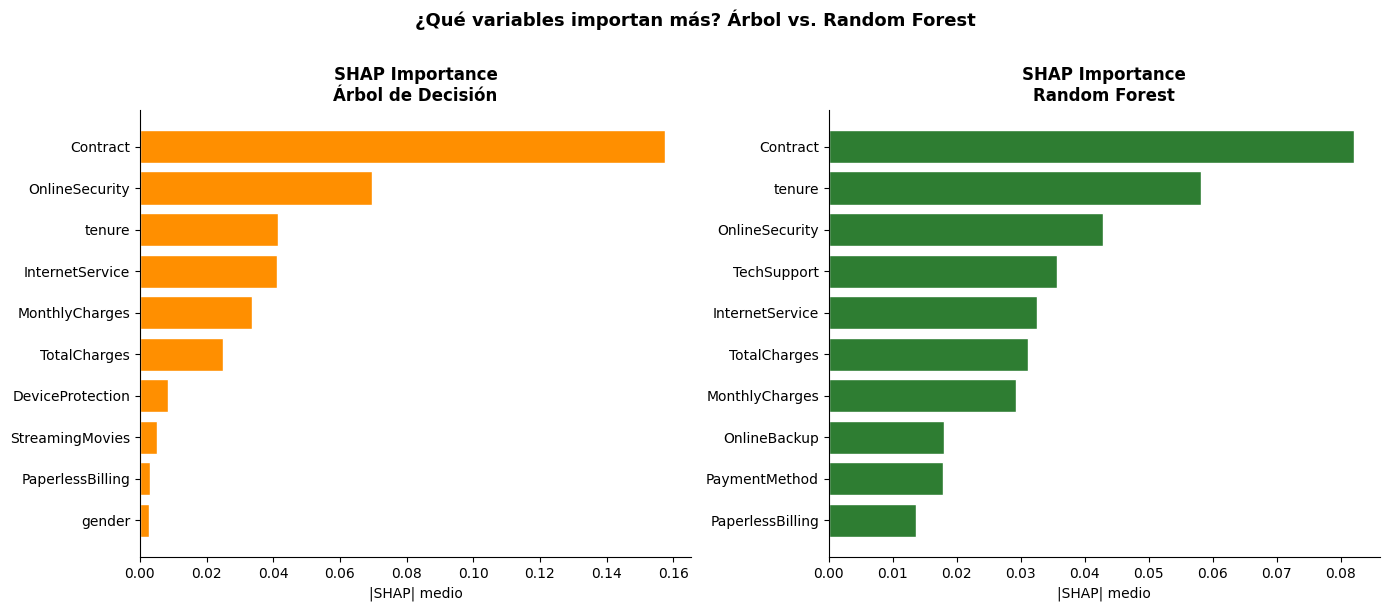


📋 Ranking de variables por importancia SHAP:
                  Rank Árbol  Rank RF Cambio
Contract                   1        1      =
tenure                     3        2     ↑1
OnlineSecurity             2        3     ↓1
TechSupport               12        4     ↑8
InternetService            4        5     ↓1
TotalCharges               6        6      =
MonthlyCharges             5        7     ↓2
OnlineBackup              16        8     ↑8
PaymentMethod             16        9     ↑7
PaperlessBilling           9       10     ↓1
MultipleLines             16       11     ↑5
StreamingTV               16       12     ↑4
StreamingMovies            8       13     ↓5
SeniorCitizen             13       14     ↓1
DeviceProtection           7       15     ↓8
gender                    10       16     ↓6
Dependents                11       17     ↓6
Partner                   16       18     ↓2
PhoneService              16       19     ↓3


In [ ]:
# Calcular SHAP del árbol de decisión para comparar
explainer_dt   = shap.TreeExplainer(dt)
shap_values_dt = explainer_dt.shap_values(X_test)

if isinstance(shap_values_dt, list):
    shap_churn_dt = shap_values_dt[1]
else:
    shap_churn_dt = shap_values_dt[:, :, 1]

# Importancia media SHAP para cada modelo
imp_dt = pd.Series(np.abs(shap_churn_dt).mean(axis=0), index=FEATURES).sort_values()
imp_rf = pd.Series(np.abs(shap_churn_rf).mean(axis=0), index=FEATURES).sort_values()

top_n = 10
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(imp_dt.tail(top_n).index, imp_dt.tail(top_n).values,
             color=C_TREE, edgecolor='white')
axes[0].set_title('SHAP Importance\nÁrbol de Decisión', fontweight='bold')
axes[0].set_xlabel('|SHAP| medio')

axes[1].barh(imp_rf.tail(top_n).index, imp_rf.tail(top_n).values,
             color=C_FOREST, edgecolor='white')
axes[1].set_title('SHAP Importance\nRandom Forest', fontweight='bold')
axes[1].set_xlabel('|SHAP| medio')

plt.suptitle('¿Qué variables importan más? Árbol vs. Random Forest',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Tabla comparativa de rankings
rank_dt = imp_dt.rank(ascending=False).astype(int)
rank_rf = imp_rf.rank(ascending=False).astype(int)
ranking = pd.DataFrame({'Rank Árbol': rank_dt, 'Rank RF': rank_rf})
ranking['Cambio'] = ranking['Rank Árbol'] - ranking['Rank RF']
ranking['Cambio'] = ranking['Cambio'].apply(
    lambda x: f'↑{x}' if x > 0 else (f'↓{abs(x)}' if x < 0 else '=')
)
print('\n📋 Ranking de variables por importancia SHAP:')
print(ranking.sort_values('Rank RF').to_string())

### 🔍 8.3 Waterfall — Explicando una predicción concreta

🎯 Cliente 1
   Prob. churn (RF):    77.0%
   Prob. churn (Árbol): 82.6%
   Churn real:          NO



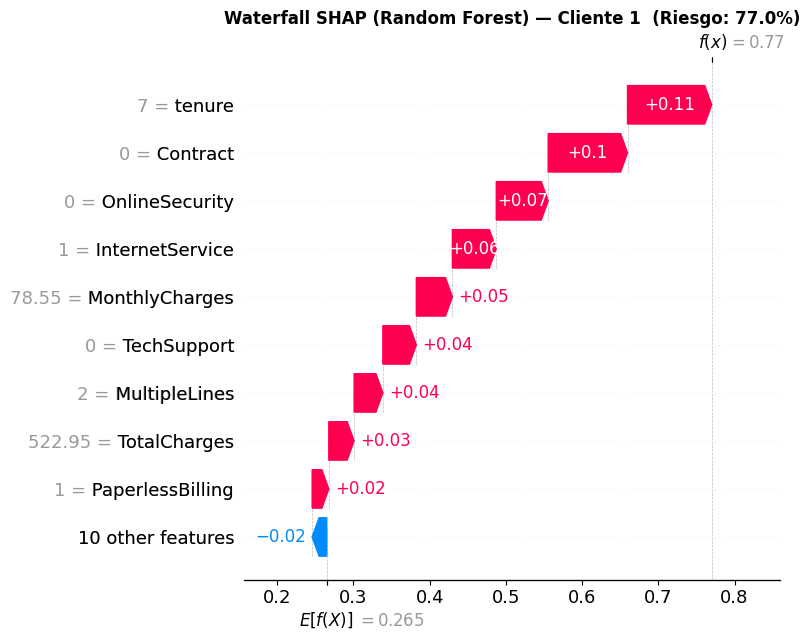

In [ ]:
# Cliente con alta probabilidad de churn según el Random Forest
high_risk = np.where(y_prob_rf >= 0.70)[0]
idx = high_risk[0] if len(high_risk) > 0 else np.argmax(y_prob_rf)

base_rf = explainer_rf.expected_value
if isinstance(base_rf, (list, np.ndarray)):
    base_rf = base_rf[1]

exp_rf = shap.Explanation(
    values       = shap_churn_rf[idx],
    base_values  = base_rf,
    data         = X_test.iloc[idx].values,
    feature_names= FEATURES
)

print(f'🎯 Cliente {idx}')
print(f'   Prob. churn (RF):    {y_prob_rf[idx]:.1%}')
print(f'   Prob. churn (Árbol): {y_prob_dt[idx]:.1%}')
print(f'   Churn real:          {"SÍ" if y_test.iloc[idx]==1 else "NO"}')
print()

plt.figure(figsize=(10, 5))
shap.plots.waterfall(exp_rf, show=False)
plt.title(f'Waterfall SHAP (Random Forest) — Cliente {idx}  '
          f'(Riesgo: {y_prob_rf[idx]:.1%})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🗺️ 9. ¿Cuándo usar árbol de decisión y cuándo Random Forest?

| Situación | Árbol de Decisión | Random Forest |
|---|---|---|
| Necesitas explicar el modelo a no técnicos | ✅ Ideal | ❌ No se puede 'mostrar' |
| Quieres la máxima precisión posible | ❌ Limitado | ✅ Mucho mejor |
| Dataset pequeño (<500 filas) | ✅ Funciona | ⚠️ Puede ser excesivo |
| Dataset grande (>10K filas) | ⚠️ Overfitting fácil | ✅ Muy robusto |
| Necesitas velocidad de entrenamiento | ✅ Muy rápido | ⚠️ Más lento (100 árboles) |
| Primera exploración / baseline | ✅ Buen punto de partida | ✅ También válido |
| Variables con muchos outliers | ⚠️ Sensible | ✅ Robusto |
| Producción / modelo final | ❌ Raramente | ✅ Sí, muy usado |

> **Regla práctica:**
> Empieza siempre con el árbol de decisión para entender los datos.
> Cuando necesites más precisión o más robustez, pasa a Random Forest.
> Si necesitas aún más precisión, el siguiente paso es XGBoost.

---
## 💼 10. Del modelo a las decisiones de negocio

In [ ]:
# Segmentación final por riesgo con el Random Forest
df_resultado = X_test.copy()
df_resultado['prob_churn_rf']   = y_prob_rf
df_resultado['prob_churn_dt']   = y_prob_dt
df_resultado['churn_real']      = y_test.values

df_resultado['segmento'] = pd.cut(
    df_resultado['prob_churn_rf'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Bajo (<30%)', 'Medio (30-60%)', 'Alto (>60%)']
)

seg = df_resultado.groupby('segmento', observed=True).agg(
    clientes       = ('prob_churn_rf', 'count'),
    churn_real_pct = ('churn_real', 'mean'),
    prob_media_rf  = ('prob_churn_rf', 'mean'),
).round(3)

print('📊 SEGMENTACIÓN FINAL CON RANDOM FOREST')
print('=' * 55)
print(seg.to_string())
print()

# Diferencia en clientes de alto riesgo detectados
alto_rf = (df_resultado['segmento'] == 'Alto (>60%)').sum()
alto_dt = (y_prob_dt > 0.60).sum()
churns_reales = df_resultado['churn_real'].sum()

# Verdaderos positivos de cada modelo en el segmento alto
tp_rf = df_resultado[df_resultado['segmento']=='Alto (>60%)']['churn_real'].sum()
tp_dt = df_resultado[y_prob_dt > 0.60]['churn_real'].sum()

print('📌 IMPACTO DE NEGOCIO: Árbol vs. Random Forest')
print('-' * 55)
print(f'  Clientes detectados en zona de alto riesgo:')
print(f'    Árbol de Decisión : {alto_dt:>4}  ({tp_dt} eran churn real)')
print(f'    Random Forest     : {alto_rf:>4}  ({tp_rf} eran churn real)')
print()
print(f'  Total churns reales en test: {churns_reales}')
print(f'  Recall (% de churns capturados en zona alta):')
print(f'    Árbol : {tp_dt/churns_reales:.0%}')
print(f'    RF    : {tp_rf/churns_reales:.0%}')
print()
print('  → El Random Forest detecta más clientes en riesgo real.')
print('    Cada cliente adicional detectado = potencial retención antes de que se vaya.')

📊 SEGMENTACIÓN FINAL CON RANDOM FOREST
                clientes  churn_real_pct  prob_media_rf
segmento                                               
Bajo (<30%)          723           0.138          0.120
Medio (30-60%)       304           0.398          0.434
Alto (>60%)          221           0.674          0.774

📌 IMPACTO DE NEGOCIO: Árbol vs. Random Forest
-------------------------------------------------------
  Clientes detectados en zona de alto riesgo:
    Árbol de Decisión :  226  (146 eran churn real)
    Random Forest     :  221  (149 eran churn real)

  Total churns reales en test: 374
  Recall (% de churns capturados en zona alta):
    Árbol : 39%
    RF    : 40%

  → El Random Forest detecta más clientes en riesgo real.
    Cada cliente adicional detectado = potencial retención antes de que se vaya.


---
## ✅ 11. Resumen

| Concepto | Lo esencial |
|---|---|
| **Bagging** | Entrenar múltiples modelos en muestras distintas y combinar sus predicciones |
| **Bootstrap** | Muestreo con reemplazo — cada árbol ve datos distintos |
| **Feature Sampling** | Cada nodo evalúa solo √n variables → fuerza diversidad |
| **Voting** | La clase mayoritaria de los 100 árboles gana |
| **OOB Score** | Validación gratuita usando el 37% de datos no vistos por cada árbol |
| **n_estimators** | Más árboles = más estable, pero rendimientos decrecientes a partir de ~100 |
| **max_features** | `'sqrt'` es el valor por defecto y funciona bien en casi todos los casos |
| **SHAP en RF** | Funciona igual que en el árbol — TreeExplainer promedia sobre los 100 árboles |

### La progresión de modelos que estamos construyendo
```
✅ Árbol de Decisión  →  interpretable, baseline, overfitting fácil
✅ Random Forest      →  más robusto, mejor precisión, sigue siendo explicable con SHAP
⏭  XGBoost            →  árboles en secuencia, máxima precisión, siguiente notebook
```

---
## 🏋️ Ejercicios para practicar

1. **Cambia `n_estimators` a 10 y a 500**. ¿Cuánto tarda más en entrenar? ¿Cuánto mejora el AUC?
2. **Prueba `max_features='log2'`**. ¿Es mejor o peor que `'sqrt'` en este dataset?
3. **Activa `oob_score=True`** y compara el OOB Score con el Test Score.
   Si difieren mucho, ¿qué problema podría haber?
4. **Mira el ranking de variables SHAP**. ¿Hay alguna variable que suba mucho
   de importancia en el RF respecto al árbol? ¿Por qué crees que ocurre?
5. **(Difícil)** Entrena un Random Forest con solo las 5 variables más importantes
   según SHAP. ¿Cuánto cae el AUC? ¿Compensa la simplicidad?
   ```python
   top5 = imp_rf.tail(5).index.tolist()
   rf_simple = RandomForestClassifier(n_estimators=100, random_state=42)
   rf_simple.fit(X_train[top5], y_train)
   ```